<a href="https://colab.research.google.com/github/Michaelfawoye/Review-Of-2019-Data-Analyst-Job-Application/blob/main/data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!uv add pandas
!uv add kaggle
!uv add matplotlib
!uv add kagglehub
!uv add seaborn
!uv add scikit-learn


Resolved 120 packages in 16ms
Audited 116 packages in 21ms
Resolved 120 packages in 1ms
Audited 116 packages in 2ms
Resolved 120 packages in 2ms
Audited 116 packages in 3ms
Resolved 120 packages in 1ms
Audited 116 packages in 3ms
Resolved 120 packages in 3ms
Audited 116 packages in 5ms
Resolved 120 packages in 2ms
Audited 116 packages in 3ms


In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split


/home/jekwu/Documents/ts-academy/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Download latest version
path = kagglehub.dataset_download("barun2104/telecom-churn")

print("Path to dataset files:", path)

Path to dataset files: /home/jekwu/.cache/kagglehub/datasets/barun2104/telecom-churn/versions/2


In [ ]:
df = pd.read_csv(path + "/telecom_churn.csv")
df.head()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


In [ ]:
print(df.shape)
print(df.ndim)
print(df.size)


(3333, 11)
2
36663


In [ ]:
# print columns of the dataframe

df.columns

Index(['Churn', 'AccountWeeks', 'ContractRenewal', 'DataPlan', 'DataUsage',
       'CustServCalls', 'DayMins', 'DayCalls', 'MonthlyCharge', 'OverageFee',
       'RoamMins'],
      dtype='str')

In [ ]:
# check the dataframe info and statistical description
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Churn            3333 non-null   int64  
 1   AccountWeeks     3333 non-null   int64  
 2   ContractRenewal  3333 non-null   int64  
 3   DataPlan         3333 non-null   int64  
 4   DataUsage        3333 non-null   float64
 5   CustServCalls    3333 non-null   int64  
 6   DayMins          3333 non-null   float64
 7   DayCalls         3333 non-null   int64  
 8   MonthlyCharge    3333 non-null   float64
 9   OverageFee       3333 non-null   float64
 10  RoamMins         3333 non-null   float64
dtypes: float64(5), int64(6)
memory usage: 286.6 KB
None
             Churn  AccountWeeks  ContractRenewal     DataPlan    DataUsage  \
count  3333.000000   3333.000000      3333.000000  3333.000000  3333.000000   
mean      0.144914    101.064806         0.903090     0.276628     0.816475   
std       0.

## Exploratory Data Analysis

<Figure size 1000x1000 with 0 Axes>

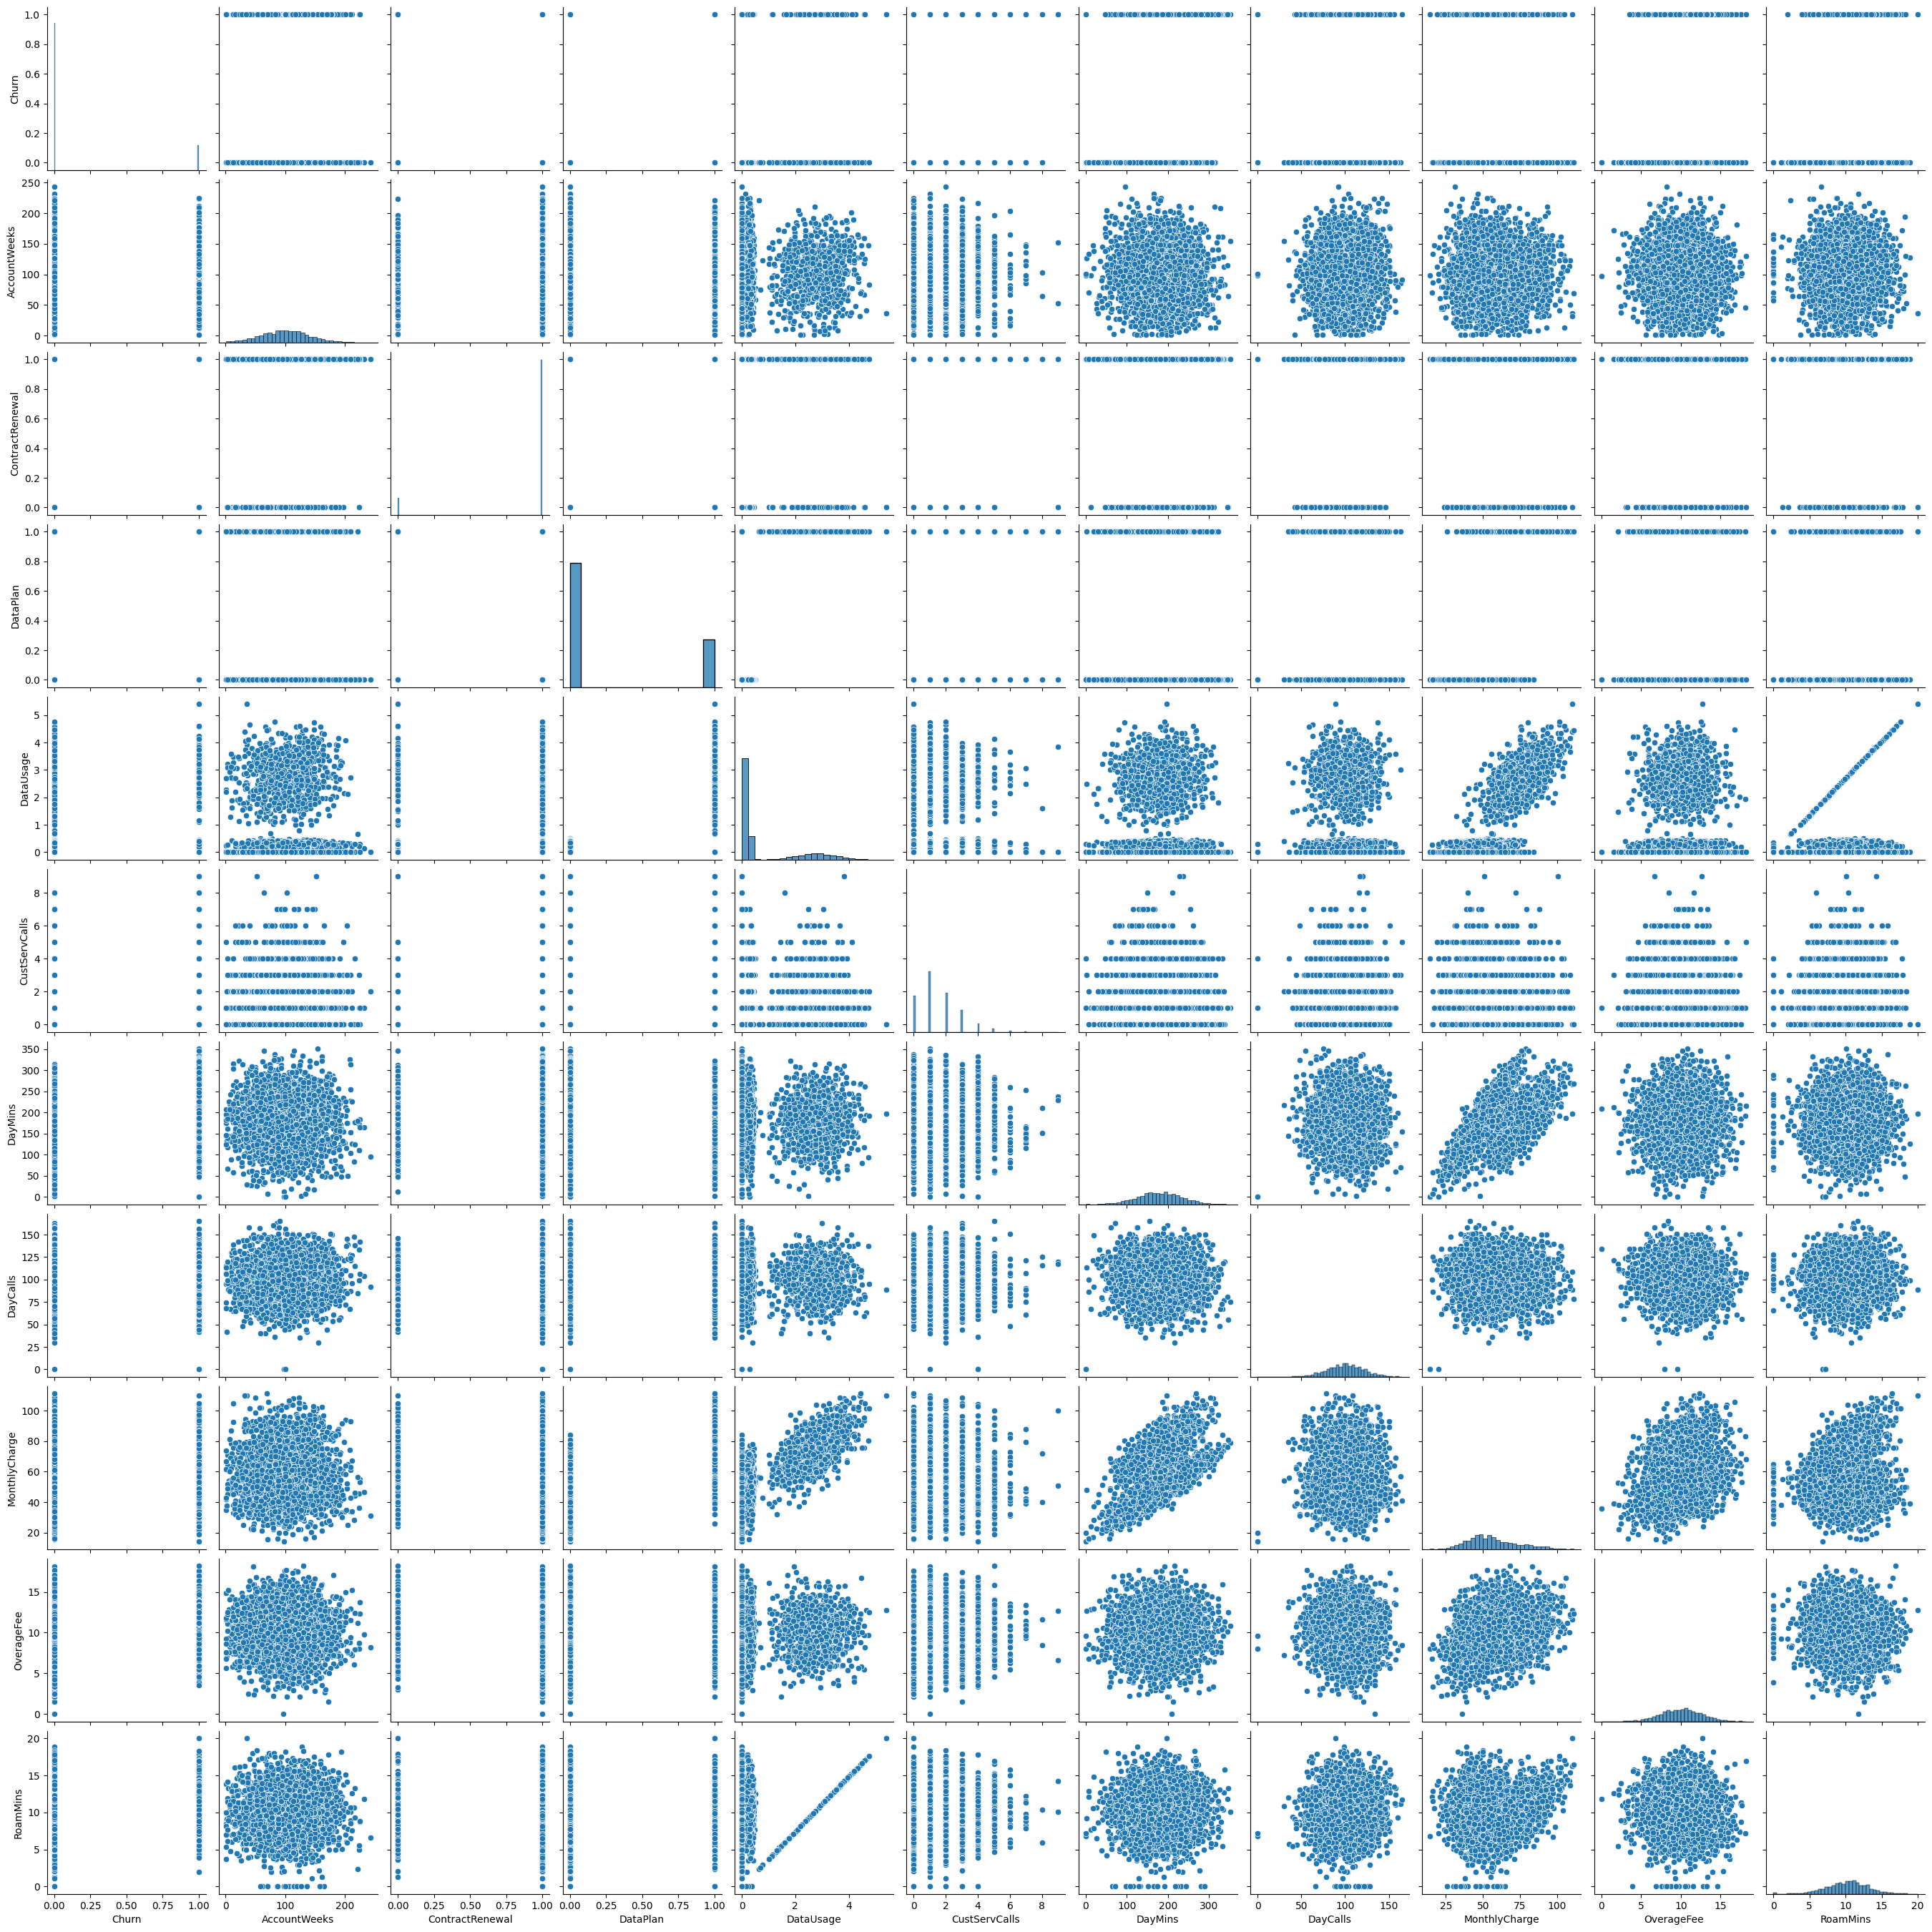

In [ ]:
# visualize the pairplots
plt.figure(figsize=(10, 10))
sns.pairplot(df)


In [ ]:
df.columns

Index(['Churn', 'AccountWeeks', 'ContractRenewal', 'DataPlan', 'DataUsage',
       'CustServCalls', 'DayMins', 'DayCalls', 'MonthlyCharge', 'OverageFee',
       'RoamMins'],
      dtype='str')

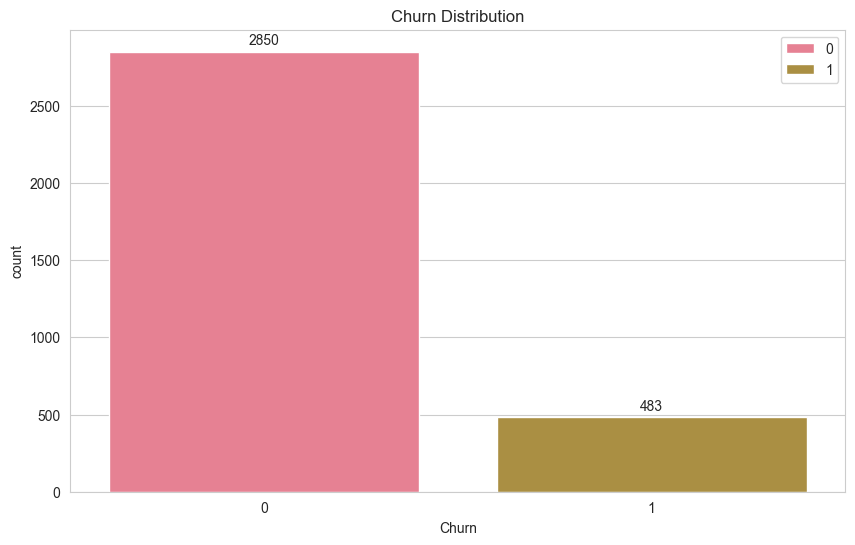

In [ ]:
sns.set_style("whitegrid")
sns.set_palette("husl")

plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x="Churn", hue="Churn")
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.title("Churn Distribution")
plt.legend()
plt.show()


In [ ]:
df["Churn"].value_counts(normalize=True)

Churn
0    0.855086
1    0.144914
Name: proportion, dtype: float64

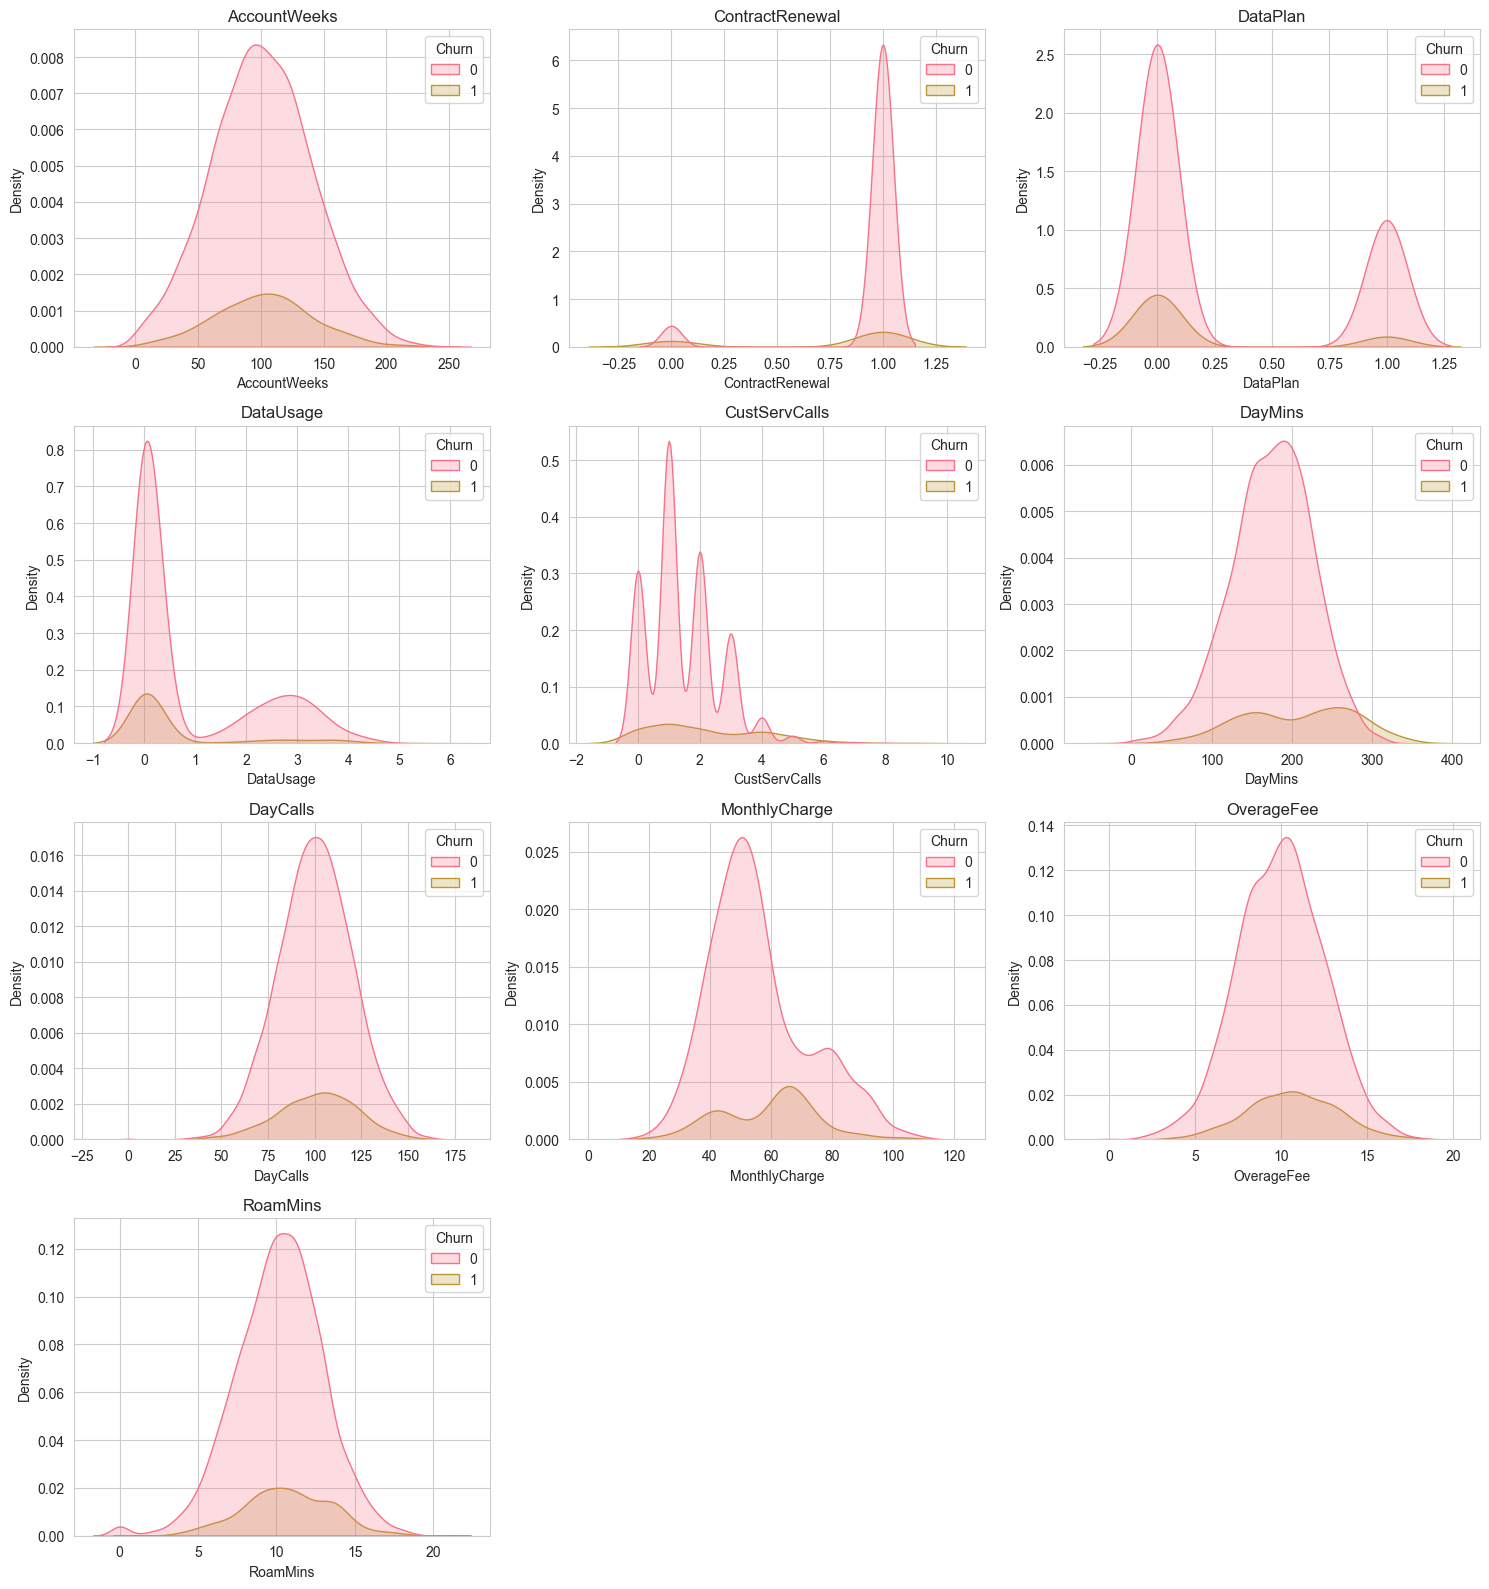

In [ ]:
# lets check the distribution of eACH OF THE featrures
feats = df.drop("Churn", axis=1).columns.tolist()

fig, axes = plt.subplots(nrows=len(feats)//3 + 1, ncols=3, figsize=(15, 4* (len(feats)//3 + 1)))
axes = axes.flatten()

feats
for i, col in enumerate(feats):
    sns.kdeplot(data=df, x=col, hue="Churn", ax=axes[i], fill=True)
    axes[i].set_title(col)

# hide any leftover empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()



In [ ]:
df['DataPlan'].value_counts()

DataPlan
0    2411
1     922
Name: count, dtype: int64

In [ ]:
df.columns

Index(['Churn', 'AccountWeeks', 'ContractRenewal', 'DataPlan', 'DataUsage',
       'CustServCalls', 'DayMins', 'DayCalls', 'MonthlyCharge', 'OverageFee',
       'RoamMins'],
      dtype='str')

In [ ]:
# check the value counts of customer service calls
df['CustServCalls'].value_counts()

CustServCalls
1    1181
2     759
0     697
3     429
4     166
5      66
6      22
7       9
9       2
8       2
Name: count, dtype: int64

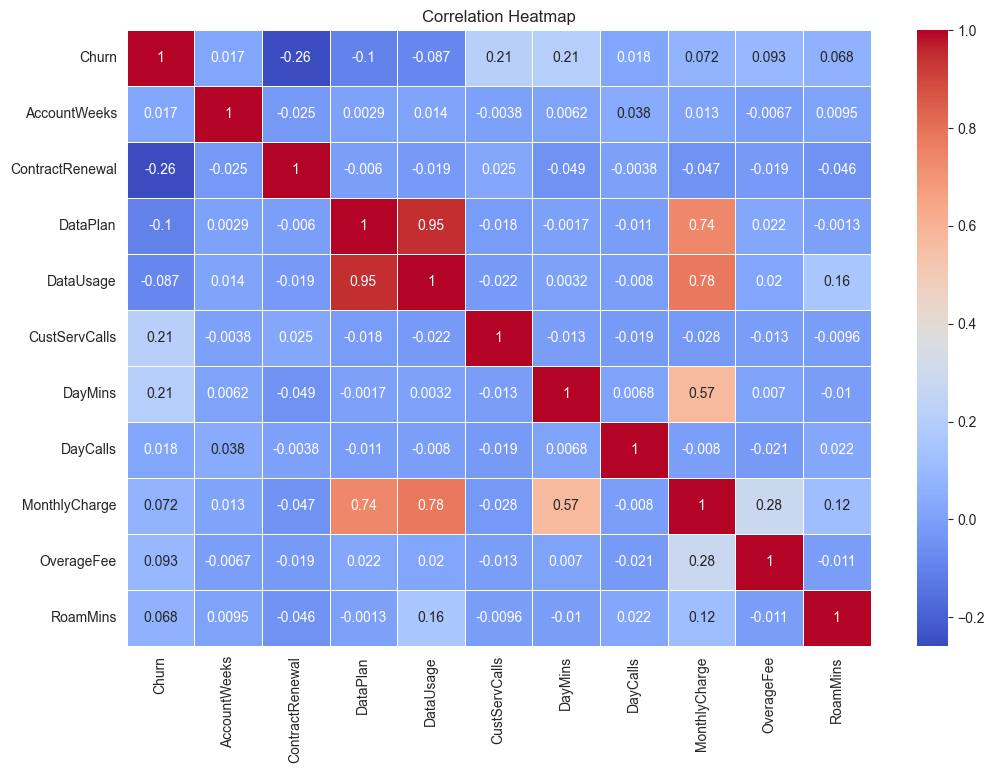

In [ ]:
# create correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

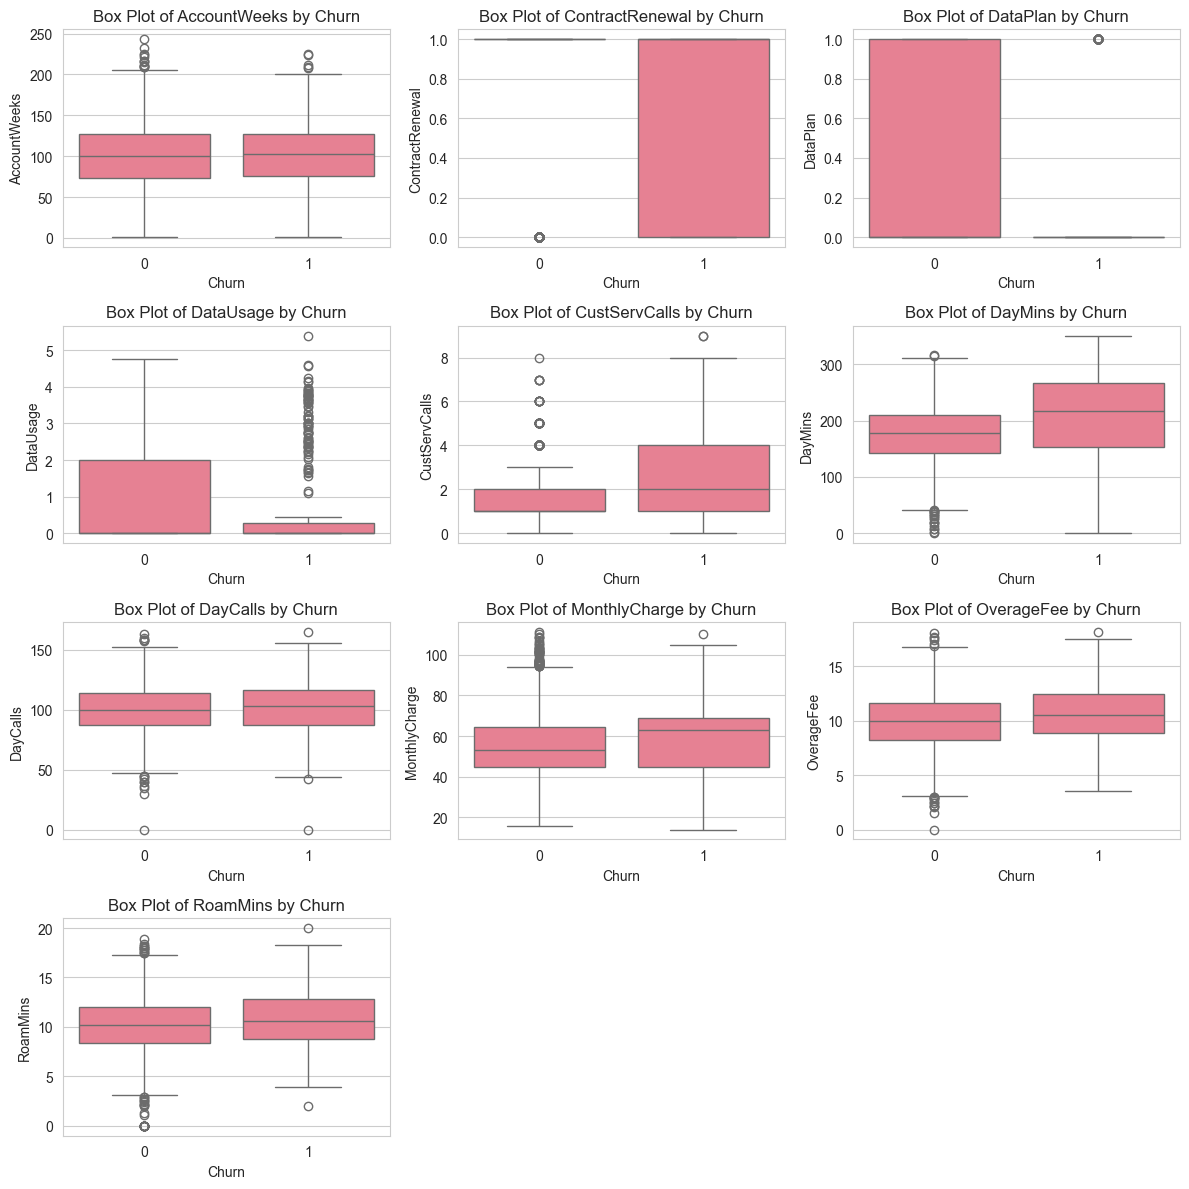

In [ ]:
# box plots for outlier detection
plt.figure(figsize=(12, 12))
for i, col in enumerate(feats):
    plt.subplot(4, 3, i + 1)
    sns.boxplot(data=df, x="Churn", y=col)
    plt.title(f'Box Plot of {col} by Churn')
plt.tight_layout()
plt.show()

## Data Dictionary

| Feature | Type | Description |
|---------|------|-------------|
| **Churn** | Binary (0/1) | Target variable. 1 = customer left the service, 0 = customer stayed |
| **AccountWeeks** | Integer | Number of weeks the customer has had an active account |
| **ContractRenewal** | Binary (0/1) | Whether the customer recently renewed their contract. 1 = renewed, 0 = did not renew |
| **DataPlan** | Binary (0/1) | Whether the customer has a data plan. 1 = yes, 0 = no |
| **DataUsage** | Float (GB) | Average monthly data usage in gigabytes |
| **CustServCalls** | Integer | Number of calls made to customer service |
| **DayMins** | Float (minutes) | Total daytime minutes used per month |
| **DayCalls** | Integer | Total number of daytime calls made per month |
| **MonthlyCharge** | Float ($) | Average monthly bill amount in dollars |
| **OverageFee** | Float ($) | Largest overage fee charged in the last 12 months |
| **RoamMins** | Float (minutes) | Total roaming minutes used per month |

---

## EDA Summary & Key Findings

### Dataset Overview
- **3,333 rows, 11 columns** — all numeric, zero missing values
- **Target**: `Churn` (binary: 0 = stayed, 1 = left)
- 5 float columns, 6 integer columns, memory usage ~287 KB

### Class Imbalance
- **85.5%** did not churn (2,850 customers)
- **14.5%** churned (483 customers)
- Dataset is imbalanced — accuracy alone won't be a reliable model metric

### Feature Distributions

| Feature | Mean | Std | Min | Max | Key Insight |
|---------|------|-----|-----|-----|-------------|
| AccountWeeks | 101.1 | 39.8 | 1 | 243 | Evenly spread, no clear churn separation |
| ContractRenewal | 0.90 | 0.30 | 0 | 1 | 90% renewed — churners heavily concentrated at 0 |
| DataPlan | 0.28 | 0.45 | 0 | 1 | 72% have no data plan (2,411 vs 922) |
| DataUsage | 0.82 | 1.27 | 0.0 | 5.4 | Right-skewed, most use little data |
| CustServCalls | 1.56 | 1.32 | 0 | 9 | Most call 0–2 times; churners call more |
| DayMins | 179.8 | 54.5 | 0.0 | 350.8 | Roughly normal; churners tend higher |
| DayCalls | 100.4 | 20.1 | 0 | 165 | Nearly normal, no meaningful churn separation |
| MonthlyCharge | 56.30 | 16.43 | 14.0 | 111.3 | Churners tend to have higher charges |
| OverageFee | 10.05 | 2.54 | 0.0 | 18.19 | Roughly normal, weak churn signal |
| RoamMins | 10.24 | 2.79 | 0.0 | 20.0 | Roughly normal, weak churn signal |

### Strongest Churn Signals
1. **ContractRenewal** — Clearest separator. Customers who didn't renew churn at a much higher rate
2. **CustServCalls** — Churners make noticeably more service calls (median higher, right-skewed for churners)
3. **DayMins / MonthlyCharge** — Churners have higher usage and higher bills; these two are also highly correlated

### Weak Predictors
- **AccountWeeks** — distributions overlap almost completely
- **DayCalls** — nearly identical between churn groups
- **RoamMins** — slight difference but largely overlapping
- **OverageFee** — minimal separation

### Correlation Insights
- **DataPlan ↔ DataUsage ↔ MonthlyCharge** — strongly correlated (redundant). Having a data plan drives usage, which drives charges. Consider dropping 1–2 before modeling
- **DayMins ↔ MonthlyCharge** — also correlated (minutes drive charges)
- **Churn** has modest positive correlation with `CustServCalls` and `DayMins`, negative correlation with `ContractRenewal`

### Outliers
- **CustServCalls** — outliers at 7–9 calls (rare but strongly associated with churn)
- **DayMins** — some values near 0 and above 300
- **DataUsage** — right-skewed with upper outliers at ~5.4 GB

### Implications for Modeling
- The model should lean heavily on **ContractRenewal**, **CustServCalls**, and **DayMins/MonthlyCharge**
- Watch for **multicollinearity** in the DataPlan/DataUsage/MonthlyCharge cluster
- Use **stratified train/test split** due to class imbalance
- Evaluate with **F1-score, precision, recall, or AUC-ROC** — not just accuracy